# Technical Case: Failure Analysis in an FPSO
---

## Dataset

The dataset contains anonymized time series records of a machine's operation from an **FPSO** (*Floating Production Storage and Offloading*).

### Recorded Variables

The recorded variables are as follows:

* **`Cycle`**: Sequential identifier of measurement cycles.
* **`Preset_1` & `Preset_2`**: Variables that control a specific operating point of the machine.
* **`Temperature`**: Temperature recorded in the equipment.
* **`Vibrations (X, Y & Z)`**: Vibrations along the machine's axes.
* **`Frequency`**: Operating frequency of the machine.
* **`Fail`**: Variable indicating whether the machine is in a failure state at the given timestamp.

---

## Tasks

> **Note:** During the FPSO’s operation, various factors can cause the machine to fail and prolong its failure state. Explore the available data, identify, and calculate the metrics required below.

### 1. Calculate how many times the equipment has failed

### 2. Categorize equipment failures by setup configurations (`Preset 1` and `Preset 2`)

### 3. Categorize equipment failures by their nature/root cause

### 4. Create a model (or models) and measure its performance

### 5. Analyze variable importance


# Importing Libs

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Loading Data

In [4]:
df = pd.read_excel("data/Test O_G_Equipment_Data.xlsx")

In [6]:
df.head()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.235186,47.657254,46.441769,64.820327,66.454520,44.483250,False
1,2,2,4,60.807234,63.172076,62.005951,80.714431,81.246405,60.228715,False
2,3,2,1,79.027536,83.032190,82.642110,98.254386,98.785196,80.993479,False
3,4,2,3,79.716242,100.508634,122.362321,121.363429,118.652538,80.315567,False
4,5,2,5,39.989054,51.764833,42.514302,61.037910,50.716469,64.245166,False


In [7]:
df.tail()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
795,796,2,6,50.469522,98.235421,151.585252,99.341380,148.838481,49.841400,True
796,797,1,4,49.985270,160.433640,110.953010,160.777175,109.917566,110.919290,True
797,798,1,4,79.777294,110.535405,61.334995,149.577811,129.463843,70.853353,True
798,799,2,8,79.360314,159.985443,61.762879,169.773831,130.213426,80.113540,True
799,800,3,1,80.854011,110.543701,121.032227,131.719473,90.331155,71.261717,True


# EDA

In [8]:
df.describe()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,1.988750,4.551250,69.263494,78.997945,73.860275,72.786878,71.866211,68.223449
std,231.0844,0.805875,2.293239,25.536252,32.501834,31.229631,32.739745,27.844616,29.138702
min,1.0000,1.000000,1.000000,2.089354,3.480279,3.846343,10.057744,18.784169,4.380101
25%,200.7500,1.000000,3.000000,51.040134,55.508564,50.752461,48.523982,50.787638,45.861762
50%,400.5000,2.000000,5.000000,65.906716,75.014848,69.394953,65.504770,69.319237,65.664252
75%,600.2500,3.000000,7.000000,80.527220,99.302530,90.195059,94.075572,88.891205,90.097457
max,800.0000,3.000000,8.000000,255.607829,189.995681,230.861142,193.569947,230.951134,178.090303


In [13]:
df.Fail.value_counts()

Fail
False    734
True      66
Name: count, dtype: int64

In [12]:
df.Fail.value_counts(normalize=True)

Fail
False    0.9175
True     0.0825
Name: proportion, dtype: float64

In [27]:
# Confirm Cycle is regular (no gaps, no duplicates, ordered)

diffs = df["Cycle"].diff().dropna()
print("All consecutive diffs == 1:", (diffs == 1).all())
print("Unique diff values:", diffs.unique())
print("Is monotonic increasing:", df["Cycle"].is_monotonic_increasing)

All consecutive diffs == 1: True
Unique diff values: [1.]
Is monotonic increasing: True


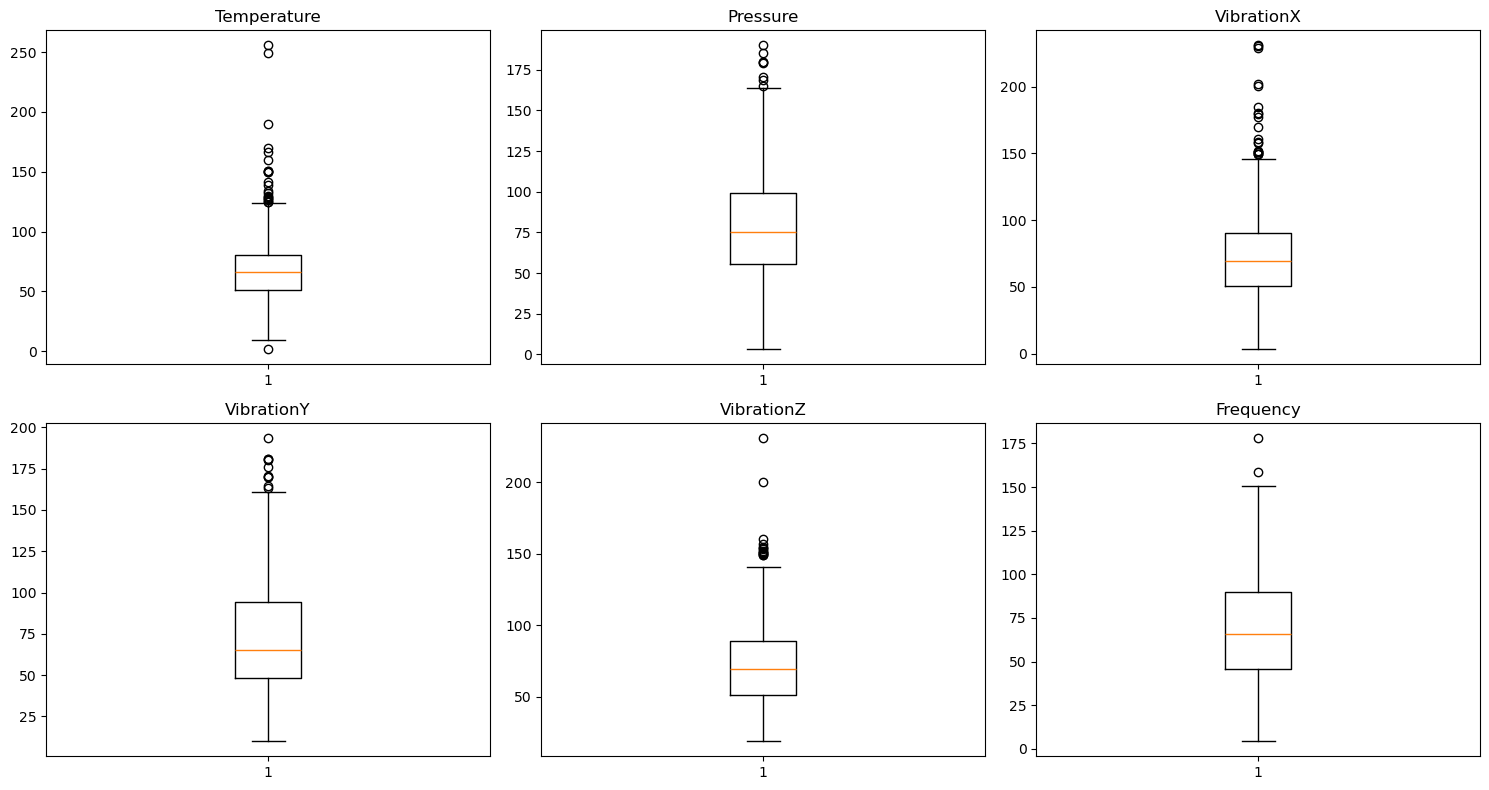

In [29]:
# Boxplots: visual outliers by the IQR rule

sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensors):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
fig.tight_layout()
plt.show()

In [30]:
# Numeric outliers by the IQR rule, flagged by machine state

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in sensors:
    mask, lower, upper = iqr_outliers(df[col])
    out = df.loc[mask, [col, "Fail"]]
    n = len(out)
    n_fail = int(out["Fail"].sum())
    print(f"{col}: {n} outliers (bounds: {lower:.1f} / {upper:.1f}) "
          f"| {n_fail} in failure, {n - n_fail} in operation")

Temperature: 22 outliers (bounds: 6.8 / 124.8) | 5 in failure, 17 in operation
Pressure: 8 outliers (bounds: -10.2 / 165.0) | 5 in failure, 3 in operation
VibrationX: 20 outliers (bounds: -8.4 / 149.4) | 5 in failure, 15 in operation
VibrationY: 10 outliers (bounds: -19.8 / 162.4) | 6 in failure, 4 in operation
VibrationZ: 14 outliers (bounds: -6.4 / 146.0) | 8 in failure, 6 in operation
Frequency: 2 outliers (bounds: -20.5 / 156.5) | 1 in failure, 1 in operation


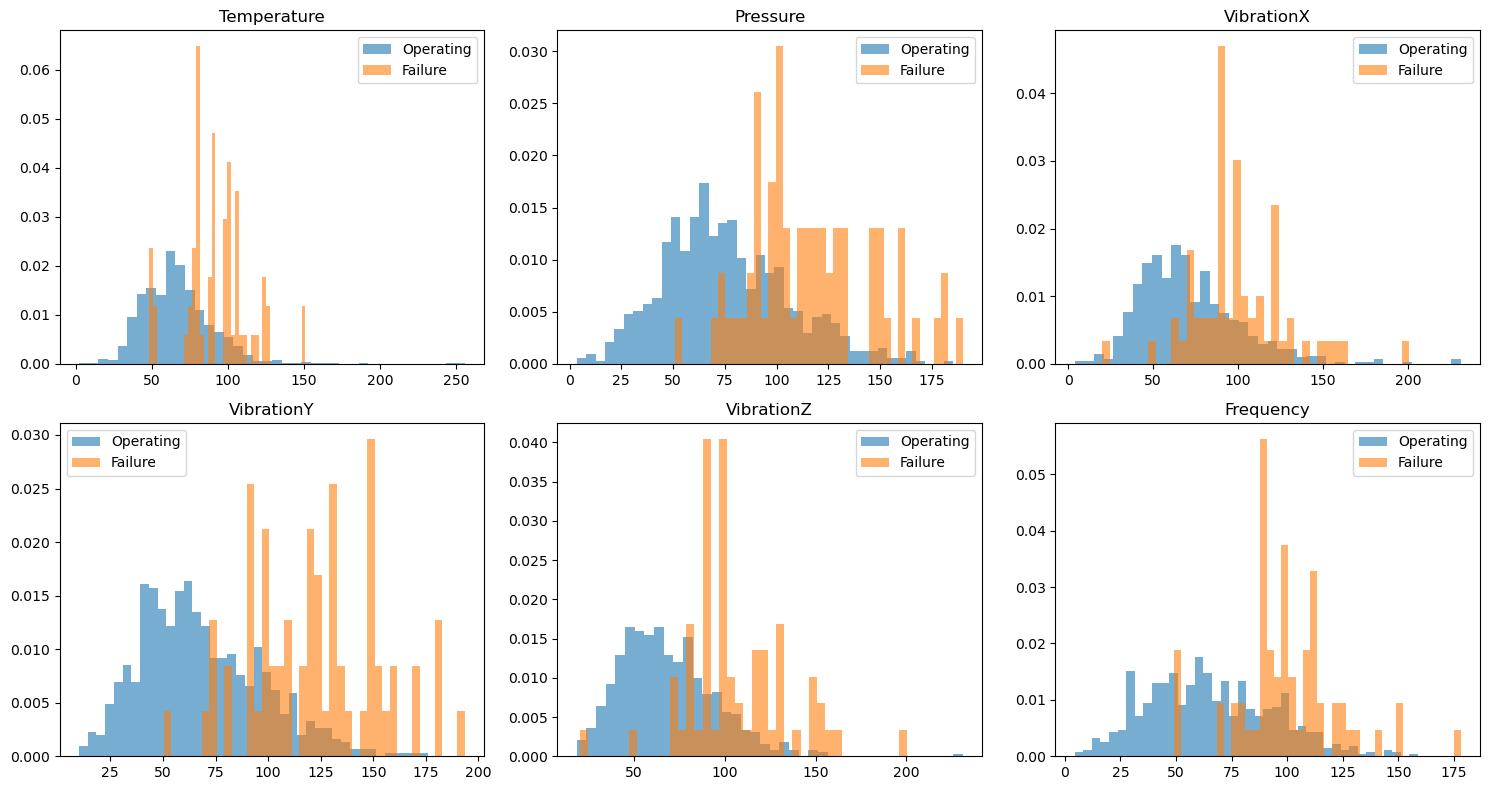

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensors):
    ax.hist(df.loc[~df["Fail"], col], bins=40, alpha=0.6, label="Operating", density=True)
    ax.hist(df.loc[df["Fail"], col], bins=40, alpha=0.6, label="Failure", density=True)
    ax.set_title(col)
    ax.legend()
fig.tight_layout()
plt.show()

<b>Initial Findings:</b>

- There are 800 instances in the dataset
- There are no missing values (every feature has 800 observations)
- Target variable (Fail) is binary
- Class imbalance: failure rows represent 8.25% of observations (91.75% vs. 8.25%). This is a per-row rate, because failures persist across consecutive cycles, the number of distinct failure events is much smaller. The effective imbalance for modeling will depend on how the prediction target is defined (see Target Definition).
- Outlier values cannot be directly associated with failures, since most outliers fall in the operating (non-failure) category. To find a reliable failure signal we likely need to look at the operating regimes (presets) and at the sensor values in the <i>n</i> cycles preceding each failure.
- Across all sensors, the failure-state distributions are shifted toward higher values (right-skewed relative to normal operation), but they overlap heavily with the operating distributions: most high values still occur during normal operation. A single-sensor threshold therefore cannot separate the classes — this overlap is what motivates a multivariate and/or temporal approach.

## Task 1

1. Calculate how many times the equipment has failed.
During the FPSO’s operation, various factors can cause the machine to fail and prolong its failure
state. We ask you to explore the available data, identify, and calculate the number of times the
equipment has failed throughout its operation.

- Transform each fail True to 1 and False to 0.
- Compute diff to previous row to detect the transition of the state of the machine, this will result in 3 outputs:
  - 0 -> no changes in the state of the machine,
  - 1 -> failure starts,
  - -1 -> machine recovery
- failure_starts = True for output == 1, False otherwise (0 or -1)
- Sum all of the time a failure starts
- Handle the edge case where the machine starts in failure mode: failure_starts.iloc[0] = (fail.iloc[0] == 1) 

In [26]:
fail = df["Fail"].astype(int)
failure_starts = (fail.diff() == 1)
failure_starts.iloc[0] = (fail.iloc[0] == 1)  
n_events = int(failure_starts.sum())
n_events

10

### task 1 anwer

number of times the equipment has failed throughout its operation = 10

## Task 2

2. Categorize equipment failures by setup configurations (Preset 1 and Preset 2). How do the variables Preset_1 and Preset_2 behave during operation? What insights can we derive from these variables?

### Analysis

In [39]:
df.Preset_1.value_counts(normalize=True)

Preset_1
2    0.35125
1    0.33000
3    0.31875
Name: proportion, dtype: float64

In [69]:
df.Preset_1.value_counts()

Preset_1
2    281
1    264
3    255
Name: count, dtype: int64

In [40]:
df.Preset_2.value_counts(normalize=True)

Preset_2
7    0.13625
6    0.12625
3    0.12625
2    0.12625
5    0.12500
8    0.12500
1    0.11875
4    0.11625
Name: proportion, dtype: float64

In [70]:
df.Preset_2.value_counts()

Preset_2
7    109
6    101
3    101
2    101
5    100
8    100
1     95
4     93
Name: count, dtype: int64

In [105]:
df.groupby("Preset_1")["Fail"].agg(["count", "sum", "mean"]).reset_index().sort_values(by=["mean"], ascending=False)

,Preset_1,count,sum,mean
0,1,264,27,0.102273
1,2,281,21,0.074733
2,3,255,18,0.070588


In [84]:
df.groupby("Preset_2")["Fail"].agg(["count", "sum", "mean"]).reset_index().sort_values(by=["mean"], ascending=False)

,Preset_2,count,sum,mean
4,5,100,12,0.120000
0,1,95,11,0.115789
1,2,101,9,0.089109
5,6,101,9,0.089109
6,7,109,9,0.082569
7,8,100,7,0.070000
2,3,101,6,0.059406
3,4,93,3,0.032258


In [107]:
df[failure_starts].groupby("Preset_1")["Fail"].agg(["count"]).reset_index().sort_values(by=["count"], ascending=False)

,Preset_1,count
0,1,5
2,3,4
1,2,1


In [108]:
df[failure_starts].groupby("Preset_2")["Fail"].agg(["count"]).reset_index().sort_values(by=["count"], ascending=False)

,Preset_2,count
0,1,3
3,6,3
1,2,2
2,3,1
4,8,1


In [109]:
pd.crosstab(df["Preset_1"], df["Preset_2"], values=df["Fail"], aggfunc="sum")

Preset_2,1,2,3,4,5,6,7,8
Preset_1,,,,,,,,
1,4,5,2,2,5,3,4,2
2,4,2,2,1,3,3,2,4
3,3,2,2,0,4,3,3,1


In [103]:
pd.crosstab(df[failure_starts]["Preset_1"], df[failure_starts]["Preset_2"], values=df["Fail"], aggfunc="sum")

Preset_2,1,2,3,6,8
Preset_1,,,,,
1,1.0,1.0,NaN,2.0,1.0
2,1.0,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,NaN


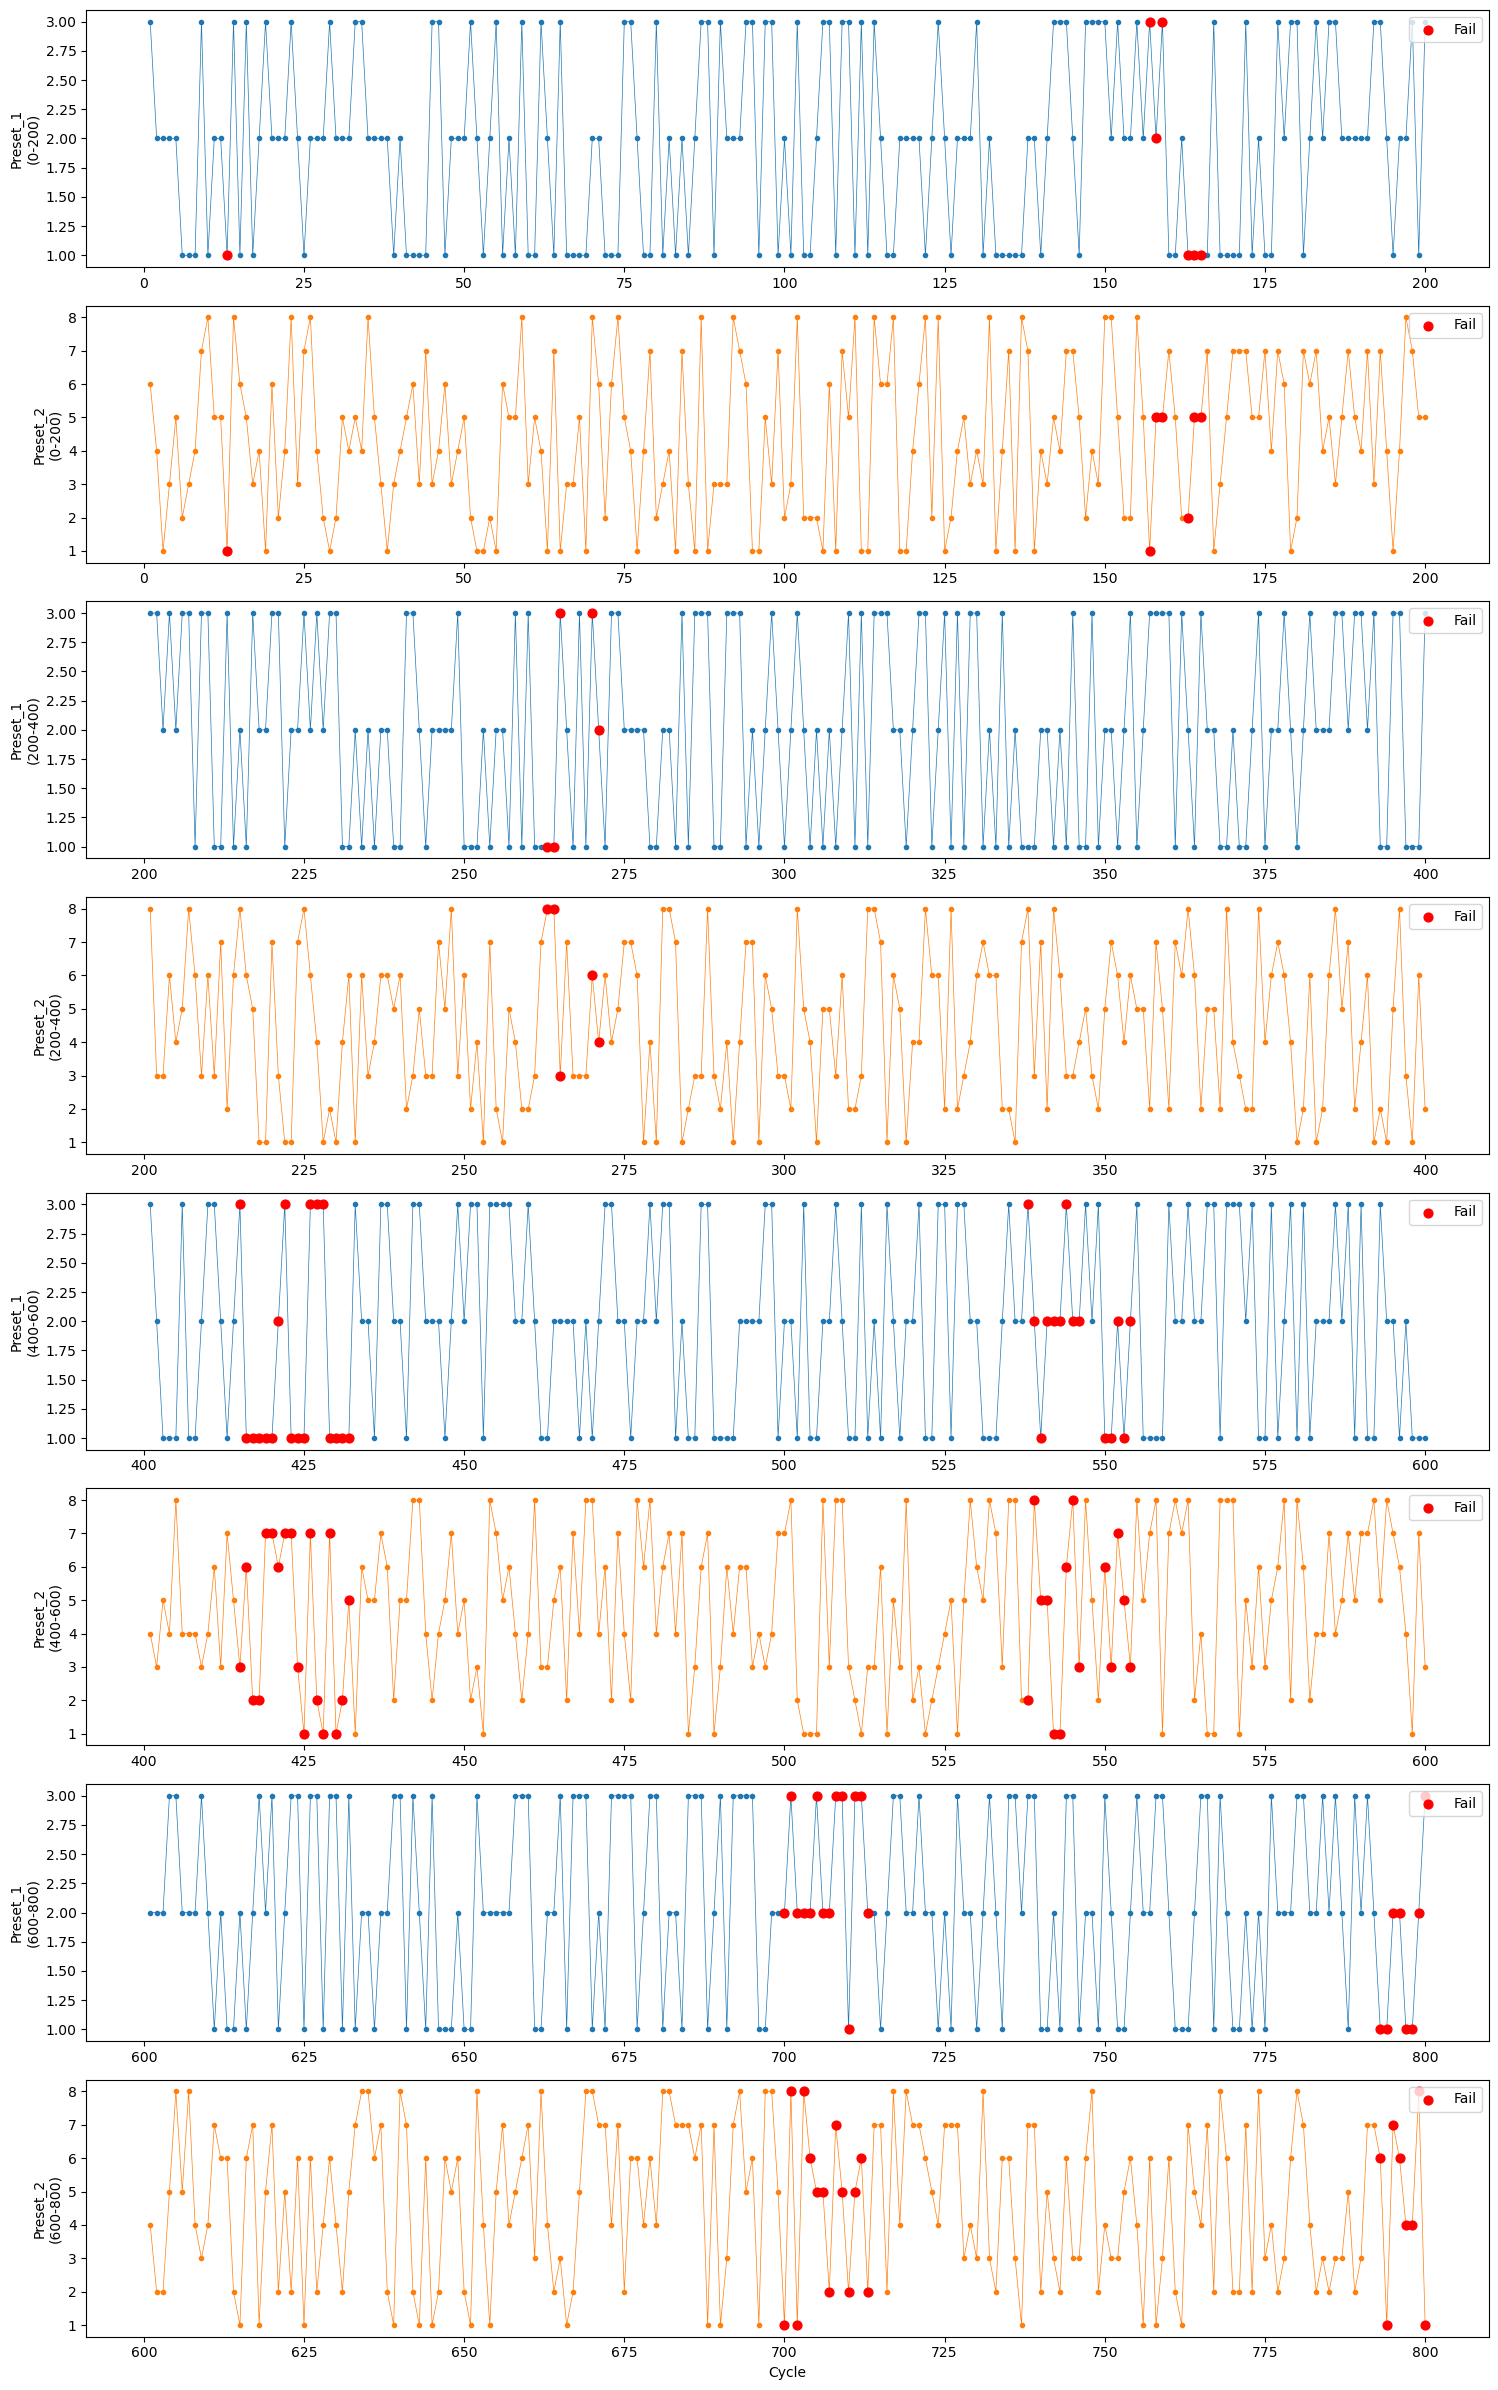

In [74]:
fail_mask = df["Fail"].values
chunk_size = 200
n_chunks = int(np.ceil(len(df) / chunk_size))

# 2 rows per chunk: Preset_1 on top, Preset_2 below
fig, axes = plt.subplots(n_chunks * 2, 1, figsize=(15, 3 * n_chunks * 2))
for i in range(n_chunks):
    lo, hi = i * chunk_size, (i + 1) * chunk_size
    seg = df.iloc[lo:hi]
    seg_fail = seg[seg["Fail"]]

    ax1 = axes[i * 2]
    ax1.plot(seg["Cycle"], seg["Preset_1"], marker=".", linewidth=0.5)
    ax1.scatter(seg_fail["Cycle"], seg_fail["Preset_1"], color="red", zorder=5, s=40, label="Fail")
    ax1.set_ylabel(f"Preset_1\n({lo}-{hi})")
    ax1.legend(loc="upper right")

    ax2 = axes[i * 2 + 1]
    ax2.plot(seg["Cycle"], seg["Preset_2"], marker=".", linewidth=0.5, color="tab:orange")
    ax2.scatter(seg_fail["Cycle"], seg_fail["Preset_2"], color="red", zorder=5, s=40, label="Fail")
    ax2.set_ylabel(f"Preset_2\n({lo}-{hi})")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Cycle")
fig.tight_layout()
plt.show()

### Task 2 answer

<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <ul style="margin:8px 0 0 0;">
    <li><strong>Sawtooth behavior.</strong> <code>Preset_1</code> and <code>Preset_2</code> change every cycle, showing no plateau or prolonged regime, they act as an instantaneous operating condition, not as extended operating phases. No regime shift is observed prior to failure.</li>
    <li><strong>Failures categorized by configuration (two complementary lenses).</strong> Per-row (marginal tables): the share of time spent in failure under each preset level. Per-event (<code>df[failure_starts]</code>): the configuration active at the moment each failure was triggered. Both are reported because they answer different questions; they converge on the same conclusion.</li>
    <li><strong>Per-event view is too sparse for conclusions.</strong> The 10 failure events are scattered across 9 of the 24 possible <code>Preset_1</code>&times;<code>Preset_2</code> combinations, with at most 2 per cell. With 10 events over 24 cells, a count of 2 in a single cell is expected by chance and does not indicate a higher-risk configuration.</li>
    <li><strong><code>Preset_1</code> marginal:</strong> level 1 shows a slightly higher failure rate (~10% vs. ~7%), but the difference is weak and likely within sampling noise.</li>
    <li><strong><code>Preset_2</code> marginal:</strong> failure rates range from ~3% to ~12% across its 8 levels, but this compares post-hoc extremes over many levels with ~100 samples each; the gap is roughly 2 standard errors and is compatible with sampling noise. No single level is reliably more failure-prone.</li>
  </ul>
  <p style="margin:8px 0 0 0;">Taken together, the failure signal is <strong>not in the instantaneous operating configuration</strong>, neither in individual presets nor in their combination. This motivates the temporal analysis that follows: the signal is likely in the <em>dynamics</em>, i.e. how sensor values evolve in the cycles preceding a failure.</p>
</div>

## Task 3

3. Categorize equipment failures by their nature/root cause according to parameter
readings (temperature, pressure, and others). </br>
Analyze patterns in these readings that could indicate specific failure types. How do these
patterns differ across operational regimes? Provide insights based on your findings.

In [111]:
sensors = ["Temperature", "Pressure", "VibrationX", "VibrationY", "VibrationZ", "Frequency"]

# Reference statistics computed on NORMAL operation only, to avoid letting
# failure values contaminate the definition of "normal".
normal = df[~df["Fail"]]

# Global z-score: how far each value is from the overall normal baseline
for s in sensors:
    mu, sigma = normal[s].mean(), normal[s].std()
    df[f"{s}_z"] = (df[s] - mu) / sigma

# Per-regime z-score: "normal" defined within each Preset_1 level
# Uses transform so each row is standardized against its own regime's normal stats.
normal_stats = normal.groupby("Preset_1")[sensors].agg(["mean", "std"])

for s in sensors:
    # map each row's regime to that regime's normal mean/std
    mu = df["Preset_1"].map(normal_stats[(s, "mean")])
    sigma = df["Preset_1"].map(normal_stats[(s, "std")])
    df[f"{s}_z_regime"] = (df[s] - mu) / sigma

In [114]:
df.columns

Index(['Cycle', 'Preset_1', 'Preset_2', 'Temperature', 'Pressure',
       'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency', 'Fail',
       'Temperature_z', 'Pressure_z', 'VibrationX_z', 'VibrationY_z',
       'VibrationZ_z', 'Frequency_z', 'Temperature_z_regime',
       'Pressure_z_regime', 'VibrationX_z_regime', 'VibrationY_z_regime',
       'VibrationZ_z_regime', 'Frequency_z_regime'],
      dtype='object')

In [113]:
df[df["Fail"] == True]

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,...,VibrationX_z,VibrationY_z,VibrationZ_z,Frequency_z,Temperature_z_regime,Pressure_z_regime,VibrationX_z_regime,VibrationY_z_regime,VibrationZ_z_regime,Frequency_z_regime
12,13,1,1,79.806509,103.129738,120.753103,134.500905,115.873197,76.562856,True,...,1.619495,2.281349,1.833339,0.400089,0.469242,0.933411,1.695677,2.140223,1.730431,0.410039
156,157,3,1,91.695332,85.345796,99.890670,95.328429,124.970301,84.377355,True,...,0.933588,0.931050,2.187615,0.679743,1.064585,0.263114,0.860596,1.071736,2.428557,0.708127
157,158,2,5,88.916114,88.231887,85.140550,123.711911,88.852872,100.229131,True,...,0.448640,1.909446,0.781065,1.247024,0.893154,0.440466,0.431482,1.850351,0.708768,1.186540
158,159,3,5,88.768766,99.228691,89.109514,124.934221,84.306467,88.218162,True,...,0.579130,1.951580,0.604010,0.817193,0.940060,0.690426,0.524662,2.168955,0.727129,0.840953
162,163,1,2,105.969444,110.694610,89.139972,153.575928,90.299923,131.072244,True,...,0.580131,2.938877,0.837418,2.350794,1.425012,1.180038,0.650310,2.758944,0.793563,2.481592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,2,6,50.469522,98.235421,151.585252,99.341380,148.838481,49.841400,True,...,2.633183,1.069379,3.117132,-0.556181,-0.735348,0.789411,2.722943,1.012736,3.043681,-0.579635
796,797,1,4,49.985270,160.433640,110.953010,160.777175,109.917566,110.919290,True,...,1.297292,3.187108,1.601404,1.629588,-0.620171,2.801612,1.371613,2.992525,1.512249,1.715707
797,798,1,4,79.777294,110.535405,61.334995,149.577811,129.463843,70.853353,True,...,-0.334030,2.801060,2.362610,0.195765,0.468175,1.174848,-0.269132,2.629260,2.228320,0.193058
798,799,2,8,79.360314,159.985443,61.762879,169.773831,130.213426,80.113540,True,...,-0.319962,3.497229,2.391802,0.527156,0.488394,2.943386,-0.374737,3.433499,2.318709,0.481455


In [115]:
df[failure_starts]

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,...,VibrationX_z,VibrationY_z,VibrationZ_z,Frequency_z,Temperature_z_regime,Pressure_z_regime,VibrationX_z_regime,VibrationY_z_regime,VibrationZ_z_regime,Frequency_z_regime
12,13,1,1,79.806509,103.129738,120.753103,134.500905,115.873197,76.562856,True,...,1.619495,2.281349,1.833339,0.400089,0.469242,0.933411,1.695677,2.140223,1.730431,0.410039
156,157,3,1,91.695332,85.345796,99.890670,95.328429,124.970301,84.377355,True,...,0.933588,0.931050,2.187615,0.679743,1.064585,0.263114,0.860596,1.071736,2.428557,0.708127
162,163,1,2,105.969444,110.694610,89.139972,153.575928,90.299923,131.072244,True,...,0.580131,2.938877,0.837418,2.350794,1.425012,1.180038,0.650310,2.758944,0.793563,2.481592
262,263,1,8,90.295697,86.349374,75.924257,116.342009,100.129464,113.784334,True,...,0.145630,1.655401,1.220218,1.732118,0.852428,0.386344,0.213299,1.551218,1.153665,1.824589
269,270,3,6,106.468516,89.151486,129.768607,90.563206,153.327082,111.281635,True,...,1.915904,0.766790,3.291936,1.642555,1.693182,0.380252,1.791572,0.895132,3.615042,1.638553
414,415,3,3,78.862065,101.454563,200.749598,50.481820,100.000843,50.456673,True,...,4.249589,-0.614840,1.215209,-0.534162,0.518532,0.758938,4.003293,-0.590322,1.383802,-0.464945
537,538,3,2,74.816930,73.487684,130.062273,75.402959,129.391805,96.448702,True,...,1.925559,0.244207,2.359805,1.111735,0.346412,-0.101876,1.800723,0.333279,2.613558,1.125588
549,550,1,6,71.337312,91.665516,88.503928,135.525440,89.955187,125.835585,True,...,0.559219,2.316666,0.823993,2.163391,0.159850,0.559659,0.629277,2.173455,0.780934,2.282580
699,700,2,1,89.980688,89.448361,128.357867,91.605837,72.841840,106.681650,True,...,1.869522,0.802730,0.157534,1.477938,0.938247,0.482899,1.921907,0.746865,0.085545,1.412712
792,793,1,6,127.670754,131.515898,95.582845,132.053899,97.254115,97.776491,True,...,0.791957,2.197000,1.108241,1.159252,2.217793,1.858847,0.863359,2.060851,1.048328,1.216234


In [119]:
# Sanity-check the per-regime z-score denominators: each sensor's normal std
# should be similar across Preset_1 levels. A collapsed/near-zero std in one
# regime would inflate that regime's z-scores and create false extremes.

sigmas = normal.groupby("Preset_1")[sensors].std()
sigmas.round(2).reset_index()

,Preset_1,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency
0,1,27.37,30.67,30.24,30.83,27.30,26.31
1,2,23.61,28.67,29.00,29.10,25.69,28.53
2,3,23.50,32.49,32.09,26.98,23.90,28.92


In [118]:
# Quantify how close the global and per-regime z-scores are, per sensor

for s in sensors:
    diff = (df[f"{s}_z"] - df[f"{s}_z_regime"]).abs()
    print(f"{s}: mean abs diff = {diff.mean():.3f}, max abs diff = {diff.max():.3f}")

Temperature: mean abs diff = 0.054, max abs diff = 0.699
Pressure: mean abs diff = 0.049, max abs diff = 0.238
VibrationX: mean abs diff = 0.054, max abs diff = 0.297
VibrationY: mean abs diff = 0.065, max abs diff = 0.362
VibrationZ: mean abs diff = 0.071, max abs diff = 0.369
Frequency: mean abs diff = 0.048, max abs diff = 0.235


<div style="background:#f4f7f9; border-left:4px solid #1f7a8c; padding:12px 16px; margin:8px 0; font-family:sans-serif; line-height:1.6;">
  <strong style="color:#0b3d5c;">Operating regime does not modulate sensor behavior</strong>
  <p style="margin:8px 0 0 0;">Standardizing each sensor against the global normal baseline and against each regime's own normal baseline produces nearly identical z-scores: the mean absolute difference per sensor is only ~0.05–0.07 SD (max ~0.7 SD in isolated points). The per-regime normal standard deviations are also very close across <code>Preset_1</code> levels, with no collapsed or inflated denominators. Together, this indicates the <strong>normal behavior of the sensors does not depend on the operating regime</strong>.</p>
  <p style="margin:8px 0 0 0;">This answers the "how do patterns differ across operational regimes?" question with a data-backed <em>they do not differ materially</em>, and it lets us analyze failure signatures globally instead of slicing the 10 events across regimes (which would be too sparse to support conclusions). We therefore drop the <code>_z_regime</code> columns and proceed with the global z-score, since the two are equivalent here.</p>
</div>

In [123]:
regime_cols = [f"{s}_z_regime" for s in sensors]
df = df.drop(columns=regime_cols, errors="ignore")

In [124]:
df.columns

Index(['Cycle', 'Preset_1', 'Preset_2', 'Temperature', 'Pressure',
       'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency', 'Fail',
       'Temperature_z', 'Pressure_z', 'VibrationX_z', 'VibrationY_z',
       'VibrationZ_z', 'Frequency_z'],
      dtype='object')

In [127]:
# Signature of each failure at its onset: z-scores at the cycle where the failure starts.
# failure_starts is the boolean mask of False->True transitions (the 10 onset cycles).

z_cols = [f"{s}_z" for s in sensors]
onset_signatures = df.loc[failure_starts, ["Cycle"] + z_cols].reset_index(drop=True)
print(onset_signatures.round(2).to_string())

   Cycle  Temperature_z  Pressure_z  VibrationX_z  VibrationY_z  VibrationZ_z  Frequency_z
0     13           0.51        0.90          1.62          2.28          1.83         0.40
1    157           0.99        0.32          0.93          0.93          2.19         0.68
2    163           1.56        1.15          0.58          2.94          0.84         2.35
3    263           0.93        0.35          0.15          1.66          1.22         1.73
4    270           1.58        0.44          1.92          0.77          3.29         1.64
5    415           0.47        0.84          4.25         -0.61          1.22        -0.53
6    538           0.31       -0.07          1.93          0.24          2.36         1.11
7    550           0.17        0.52          0.56          2.32          0.82         2.16
8    700           0.92        0.45          1.87          0.80          0.16         1.48
9    793           2.44        1.83          0.79          2.20          1.11         1.16